## Python Programming - Airbnb Analysis

### Import libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Read in Airbnb Listings CSV

In [2]:
listings = pd.read_csv("G:/Meu Drive/_INTERCAMBIO/6. ESCOLA E EXAMES/COLLEGE/KARINA/CITY COLLEGE/01. Programming in Python/Github - Final Project/airbnb-data-analysis-python/data/airbnb_listings.csv")

### List columns in dataframe

In [3]:
listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

## 1) Review Scores Rating vs Room Type

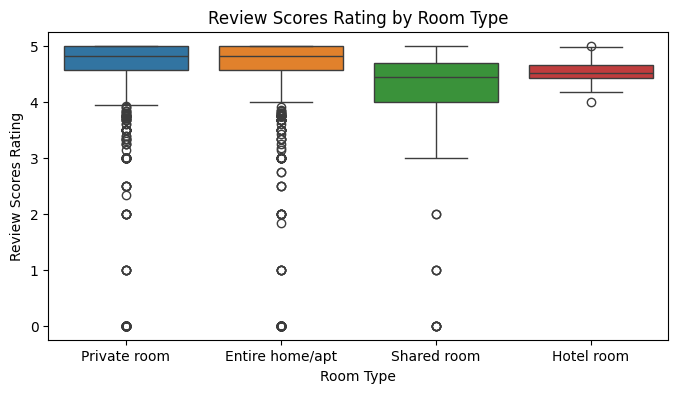

In [4]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=listings, x='room_type', y='review_scores_rating', hue='room_type')
plt.title('Review Scores Rating by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Review Scores Rating')
plt.savefig("../images/review scores_vs_room_type.png", bbox_inches="tight")
plt.show()

### Commentary
In this visualization we see that "Private room" and "Entire home/apt" have similar median review scores, both close to 5, indicating high satisfaction. "Hotel room" also shows a high median score, a little bit lower but still near 5. "Shared room," however, has a lower median score around 4. There are many outliers, especially in "Private room" and "Entire home/apt" suggests variability in guest experiences. Overall, guests rate private and entire home accommodations higher compared to shared rooms.

### Statistical Analysis

In [5]:
# Calulate the means
print("Average Review Score for Private Room:", listings[listings['room_type'] == 'Private room']['review_scores_rating'].mean())
print("Average Review Score for Entire home/apt:", listings[listings['room_type'] == 'Entire home/apt']['review_scores_rating'].mean())
print("Average Review Score for Shared room:", listings[listings['room_type'] == 'Shared room']['review_scores_rating'].mean())
print("Average Review Score for Hotel room:", listings[listings['room_type'] == 'Hotel room']['review_scores_rating'].mean())

Average Review Score for Private Room: 4.607297019527236
Average Review Score for Entire home/apt: 4.620420114576703
Average Review Score for Shared room: 4.016355140186916
Average Review Score for Hotel room: 4.529268292682927


These results above confirm the result commented in the boxplot. Guests rate private and entire home accommodations higher compared to shared rooms.

In [6]:
# Calulate the standard deviations
print("Variance for Private Room:", listings[listings['room_type'] == 'Private room']['review_scores_rating'].std())
print("Variance for Entire home/apt:", listings[listings['room_type'] == 'Entire home/apt']['review_scores_rating'].std())
print("Variance for Shared room:", listings[listings['room_type'] == 'Shared room']['review_scores_rating'].std())
print("Variance for Hotel room:", listings[listings['room_type'] == 'Hotel room']['review_scores_rating'].std())

Variance for Private Room: 0.7747027937236168
Variance for Entire home/apt: 0.7425724420722668
Variance for Shared room: 1.2720347631740767
Variance for Hotel room: 0.20456527373802286


The differences in the variances of review scores show how stable guest experiences are for each room type. "Private rooms" and "Entire home" have some outliers, but most guests are very satisfied and we have moderate variability in scores. "Shared rooms" have the most variability, suggesting guest experiences are more mixed. "Hotel rooms" have the most consistent reviews, probably because they offer standardized services, making guest satisfaction more predictable.

### New visualization with lineplot to see Review Scores Rating vs Room Type over the year

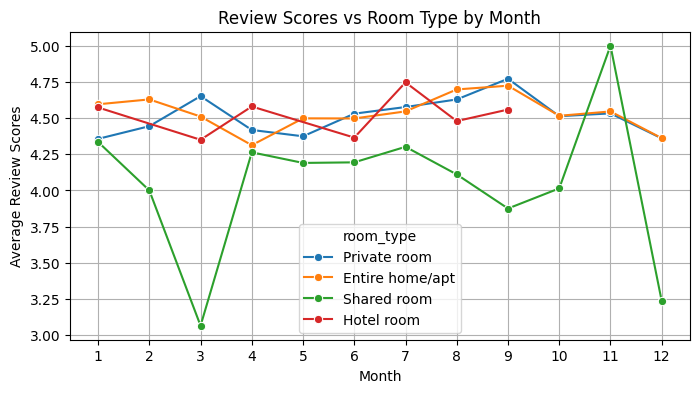

In [7]:
# Extract the month from 'last review date'
listings['month'] = pd.to_datetime(listings['last_review']).dt.month

plt.figure(figsize=(8, 4))
sns.lineplot(data=listings, x='month', y='review_scores_rating', hue='room_type', errorbar=None, estimator='mean', marker='o')
plt.title('Review Scores vs Room Type by Month')
plt.xlabel('Month')
plt.ylabel('Average Review Scores')
plt.xticks(range(1, 13))
plt.grid(True)
plt.savefig("../images/review_scores_vs_room_types_month.png", bbox_inches="tight")
plt.show()

In this visualization, we have a better idea of the trend in review scores for different room types by month. "Private room" and "Entire home/apt" have stable high review scores around 4.5 all year. "Hotel room" scores are also high and stable, slightly below 4.5. "Shared room" has more ups and downs, with a noticeable drop in April and November. This shows shared rooms have less stable reviews compared to other room types.

## 2)  Review Scores Location vs Review Scores Rating

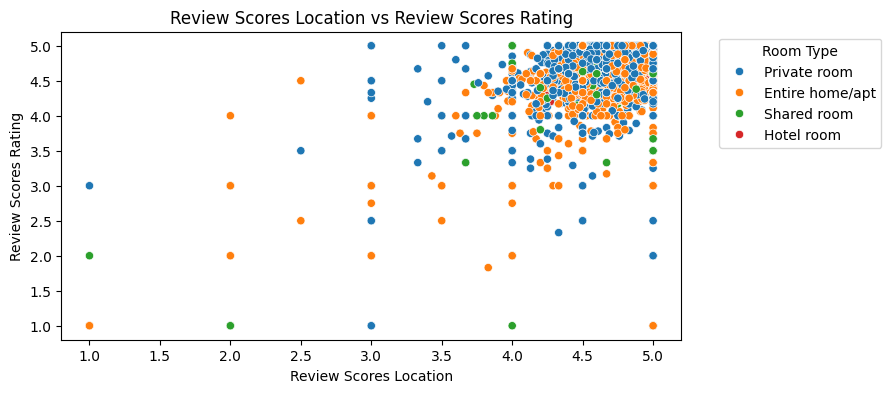

In [8]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=listings, x='review_scores_location', y='review_scores_rating', hue='room_type')
plt.title('Review Scores Location vs Review Scores Rating')
plt.xlabel('Review Scores Location')
plt.ylabel('Review Scores Rating')
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("../images/review_scores.png", bbox_inches="tight")
plt.show()

### Commentary
The scatter plot shows that places with better location scores (4.0 to 5.0) usually get higher overall ratings, meaning guests are generally more satisfied. For places with lower location scores (below 4.0), review scores vary more, suggesting other factors can compensate for a less good location. "Private rooms" have mostly high location and review scores, while the others show more variation in their ratings.

### Statistical Analysis

In [9]:
# Calculate correlation
correlation = listings[['review_scores_location', 'review_scores_rating']].corr()
correlation

,review_scores_location,review_scores_rating
review_scores_location,1.000000,0.499224
review_scores_rating,0.499224,1.000000


The correlation around 0.50 means there is a moderate positive relationship, it means that places with better location scores generally have higher overall ratings.

In [10]:
listings[['review_scores_location', 'review_scores_rating']].describe()

,review_scores_location,review_scores_rating
count,6081.000000,6209.000000
mean,4.732065,4.603239
std,0.352586,0.771441
min,1.000000,0.000000
25%,4.630000,4.560000
50%,4.820000,4.810000
75%,5.000000,5.000000
max,5.000000,5.000000


Most guests give high marks for both location and overall experience, with average scores of 4.73 for location and 4.60 for overall rating. Location scores are generally consistent (std=0.35), but overall ratings vary more (std=0.77). While a few places have very low scores, most are rated close to 5, indicating high guest satisfaction.

## 3) Price vs. Room Type

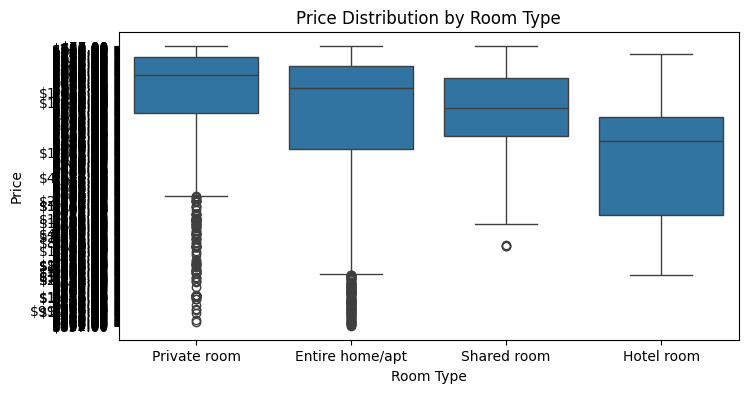

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=listings, x='room_type', y='price')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

The first plot does not show a good visualization of the data. We have some black columns on the left side of the image indicate that the prices are not being displayed correctly. To solve this, we can apply cleaning methods and ensure that the price column is correctly formatted and then recreate the plot.

In [12]:
# Clean the price column - Remove the dollar sign, Remove commas, Convert to float
listings['price'] = listings['price'].str.replace('[\$,]', '', regex=True)
listings['price'] = listings['price'].str.replace(',', '', regex=True)
listings['price'] =listings['price'] = listings['price'].astype(float)

print(listings['price'].head())

0     70.0
1     67.0
2     45.0
3     80.0
4    251.0
Name: price, dtype: float64


<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\KARIN\AppData\Local\Temp\ipykernel_26636\1481418738.py:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  listings['price'] = listings['price'].str.replace('[\$,]', '', regex=True)


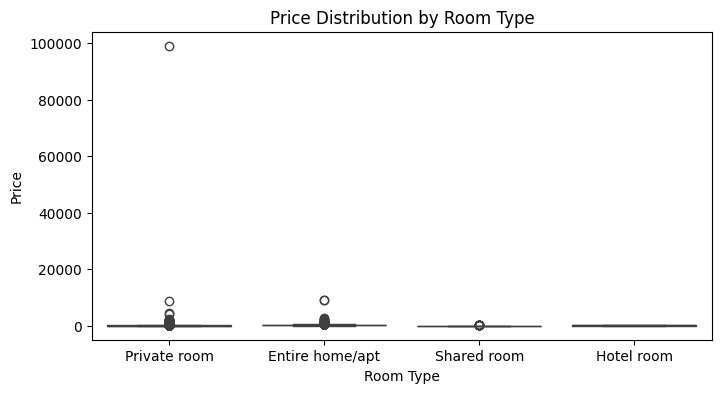

In [13]:
# Plot new boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(data=listings, x='room_type', y='price')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

Based on the previous visualization, the boxplot still has outliers, especially for "Private room". We can limit the prices to $500, reducing the impact of extremely high values.

In [14]:
# Handling Outliers
filtered_listings = listings[listings['price'] <= 500]

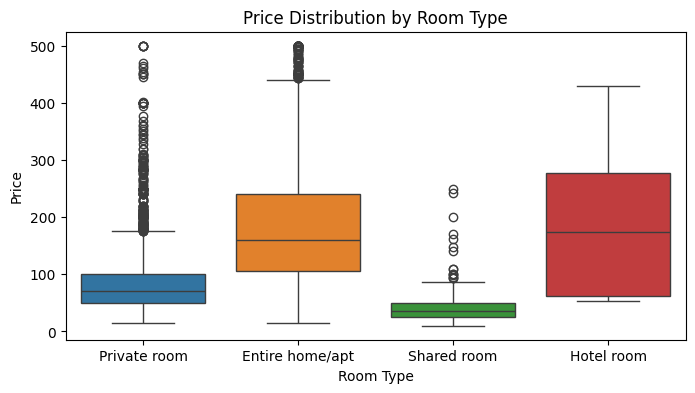

In [15]:
# New Visualization
plt.figure(figsize=(8, 4))
sns.boxplot(data=filtered_listings, x='room_type', y='price', hue='room_type')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

### Commentary
In this boxplot, "Entire home/apt" has the highest average price, with many listings over $400. "Private room" has a lower average price but lots of variation, meaning prices can differ a lot. "Shared room" is the cheapest and has more consistent prices. "Hotel room" prices are moderate with some variation. Overall, entire homes cost the most, shared rooms the least, and private rooms and hotel rooms are in the middle with varying prices.

### Statistical Analysis

In [16]:
# Calulate the means
print("Average Price for Private Room:", listings[listings['room_type'] == 'Private room']['price'].mean())
print("Average Price for Entire home/apt:", listings[listings['room_type'] == 'Entire home/apt']['price'].mean())
print("Average Price for Shared room:", listings[listings['room_type'] == 'Shared room']['price'].mean())
print("Average Price for Hotel room:", listings[listings['room_type'] == 'Hotel room']['price'].mean())

Average Price for Private Room: 151.3705557114791
Average Price for Entire home/apt: 217.79503433703115
Average Price for Shared room: 44.49142857142857
Average Price for Hotel room: 185.76190476190476


The mean prices reinforce the boxplot findings, with entire homes being the most expensive at 217.79, shared rooms the least at 44.49, and private rooms and hotel rooms in the middle at 151.37 and 185.76, respectively.

In [17]:
# Calulate the standard deviations
print("Variance for Private Room:", listings[listings['room_type'] == 'Private room']['price'].std())
print("Variance for Entire home/apt:", listings[listings['room_type'] == 'Entire home/apt']['price'].std())
print("Variance for Shared room:", listings[listings['room_type'] == 'Shared room']['price'].std())
print("Variance for Hotel room:", listings[listings['room_type'] == 'Hotel room']['price'].std())

Variance for Private Room: 1682.670428183449
Variance for Entire home/apt: 267.73774257097216
Variance for Shared room: 36.31137191991065
Variance for Hotel room: 119.40070055843209


The variances show how stable prices are for different room types. "Private room" has the most price changes (variance: 1682.67), meaning prices vary a lot. "Entire home/apt" (267.74), "Hotel room" (119.40), and "Shared room" (36.31) have more stable prices, with shared rooms being the most consistent.

### New visualization with lineplot to see Price vs. Room Type over the year

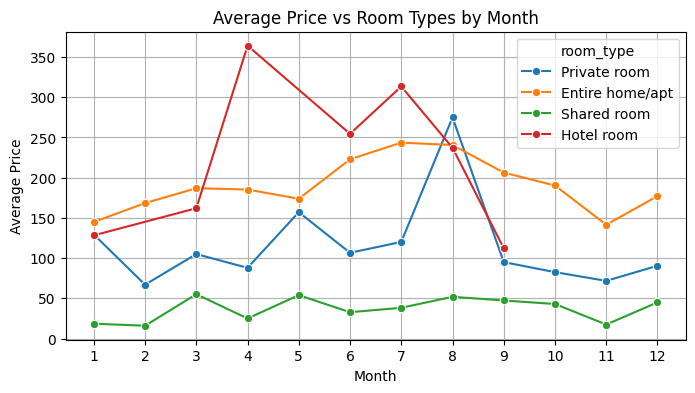

In [18]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=listings, x='month', y='price', hue='room_type', errorbar=None, estimator='mean', marker='o')
plt.title('Average Price vs Room Types by Month')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.xticks(range(1, 13))
plt.grid(True)
plt.savefig("../images/price_vs_room_type_month.png", bbox_inches="tight")
plt.show()

In this chart, we see how average prices change each month for different types of rooms. "Private room" and "Entire home/apt" have relatively stable prices, with entire homes generally being more expensive. Shared rooms have the lowest and most consistent prices. "Hotel rooms" are the most expensive and show show significant peaks in April and July, probably due to higher demand.

## 4) Price vs. Number of Reviews

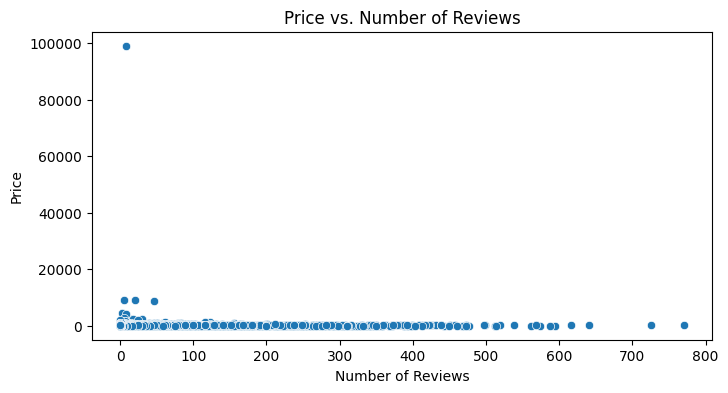

In [19]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=listings, x='number_of_reviews', y='price')
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

In this case, we can see if the number of reviews affects the price of accommodations. There is an outlier in price that costs nearly $100000. Removing this outlier will help us better understand the typical relationship between price and the number of reviews.

In [20]:
outlier = listings[listings['price'] > 90000]
outlier

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,month
6298,592358982465178083,https://www.airbnb.com/rooms/592358982465178083,20220911231053,2022-09-12,city scrape,Not available,Enjoy easy access to popular shops and restaur...,safe neigbourhood .,https://a0.muscache.com/pictures/miso/Hosting-...,342210497,...,4.38,4.38,NaN,f,2,0,2,0,2.33,8.0


The identified outlier is row 6298, so the row has to be dropped and the visualization will be displayed again.

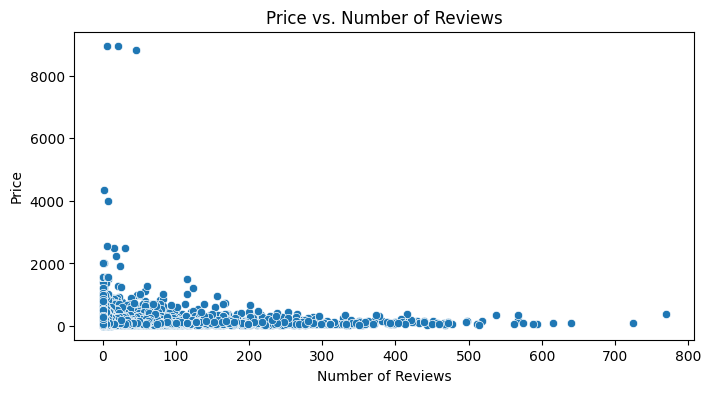

In [21]:
listings.drop(6298, inplace=True)

plt.figure(figsize=(8, 4))
sns.scatterplot(data=listings, x='number_of_reviews', y='price')
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

### Commentary
After removing the extreme outlier, we see that most listings are priced under $2,000. There is no strong correlation between the number of reviews and price. Listings with a wide range of prices can have many or few reviews. Listings with both high and low prices can have many or few reviews, suggesting that the number of reviews does not significantly affect the price.

### Statistical Analysis

In [22]:
# Calculate correlation
correlation_price_reviews = listings[['number_of_reviews', 'price']].corr()
print(correlation_price_reviews)

                   number_of_reviews     price
number_of_reviews           1.000000 -0.036281
price                      -0.036281  1.000000


The result shows the week correlation between location scores and overall ratings, as the number is closer to -1.

### New visualization with lineplot to see the trend in number of reviews by month

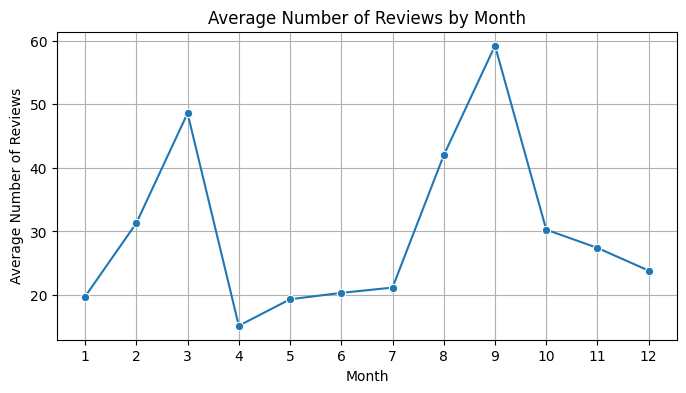

In [23]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=listings, x='month', y='number_of_reviews', errorbar=None, estimator='mean', marker='o')
plt.title('Average Number of Reviews by Month')
plt.xlabel('Month')
plt.ylabel('Average Number of Reviews')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

While there was a weak correlation between price and the number of reviews as showed before, this line plot highlights how the number of reviews varies throughout the year. We see significant peaks in March and September, imeaning more people leave reviews during these months. There is a noticeable drop in April and another decline after September. This suggests guests are more likely to leave reviews in early spring and early fall.

## 5) Availability 90 vs. Room Type

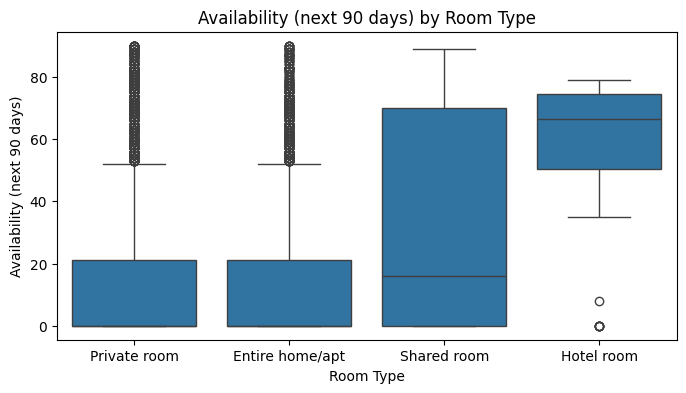

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=listings, x='room_type', y='availability_90')
plt.title('Availability (next 90 days) by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Availability (next 90 days)')
plt.show()

Analyzing the dataset, it is possible to verify that we have a lot of room types with availability as "0" for all time variables (30, 60, 90, and 365 days). Considering this, we understand that a zero value might not indicate high demand, but rather a lack of information in the dataset. Therefore, we chose to eliminate the zero values to observe the difference.

In [25]:
listings_non_zero = listings[listings['availability_90'] != 0]

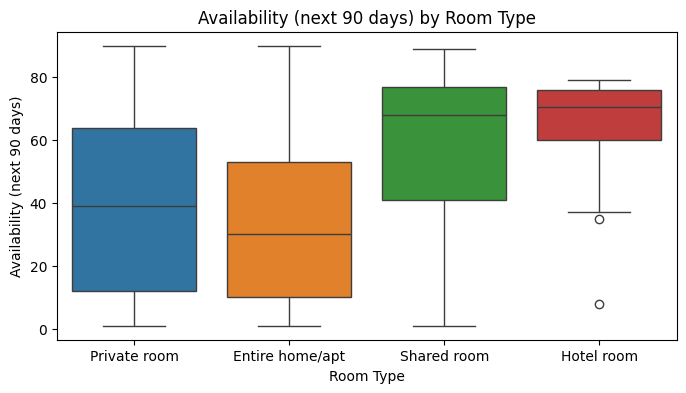

In [26]:
# Create a new boxplot with the non-zero data
plt.figure(figsize=(8, 4))
sns.boxplot(data=listings_non_zero, x='room_type', y='availability_90', hue='room_type')
plt.title('Availability (next 90 days) by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Availability (next 90 days)')
plt.savefig("../images/availability_by_room_type.png", bbox_inches="tight")
plt.show()

### Commentary
After removing zeros from the data, we can see that "Private room" and "Entire home/apt" have similar availability, with "Private room" being slightly more available. "Shared rooms" and "Hotel rooms" have the highest availability, meaning they are often free to book in the next 90 days. 

### Statistical Analysis

In [27]:
print("Average Availability for Private Room:", listings[listings['room_type'] == 'Private room']['availability_90'].mean())
print("Average Availability for Entire home/apt:", listings[listings['room_type'] == 'Entire home/apt']['availability_90'].mean())
print("Average Availability for Shared room:", listings[listings['room_type'] == 'Shared room']['availability_90'].mean())
print("Average Availability for Hotel room:", listings[listings['room_type'] == 'Hotel room']['availability_90'].mean())

Average Availability for Private Room: 14.891914654688378
Average Availability for Entire home/apt: 13.881141045958795
Average Availability for Shared room: 32.245714285714286
Average Availability for Hotel room: 55.595238095238095


Based on the average availability generated, we can see that "Private Room" and "Entire Home/Apt" have similar values, "Shared Room" has a slightly higher value (32.24), and "Hotel Room" has a high average availability (55.59) in the next 90 days.

In [28]:
# Calulate the standard deviations
print("Variance for Private Room:", listings[listings['room_type'] == 'Private room']['availability_90'].var())
print("Variance for Entire home/apt:", listings[listings['room_type'] == 'Entire home/apt']['availability_90'].var())
print("Variance for Shared room:", listings[listings['room_type'] == 'Shared room']['availability_90'].var())
print("Variance for Hotel room:", listings[listings['room_type'] == 'Hotel room']['availability_90'].var())

Variance for Private Room: 659.766747301897
Variance for Entire home/apt: 538.7203470199951
Variance for Shared room: 1190.462266009852
Variance for Hotel room: 719.6614401858305


We can see that "Private Room" and "Hotel Room" have similar high variability (659.77 and 719.66, respectively), "Entire Home/Apt" has lower variability (538.72) meaning they have  more stable availability, and "Shared Room" has the highest variability (1190.46) in availability over the next 90 days.